## Twist Evaluation
- Analysis of the structure
- Twist Evaluation
- Filtering Bad Data

In [1]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import twistaly as tw

# --- Work with an specific result ---
twist = 0
files_dir = "systems-mds"
u_filedir = files_dir + f"/twist{twist}-files"

u = md.Universe(u_filedir + "/md_1.tpr", u_filedir + "/md_1_noPBC.xtc")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Load the Data ---
atom_gp = "name CA"

protein = u.select_atoms("protein")
#atom_group = protein.select_atoms(atom_gp) 
chains = protein.fragments

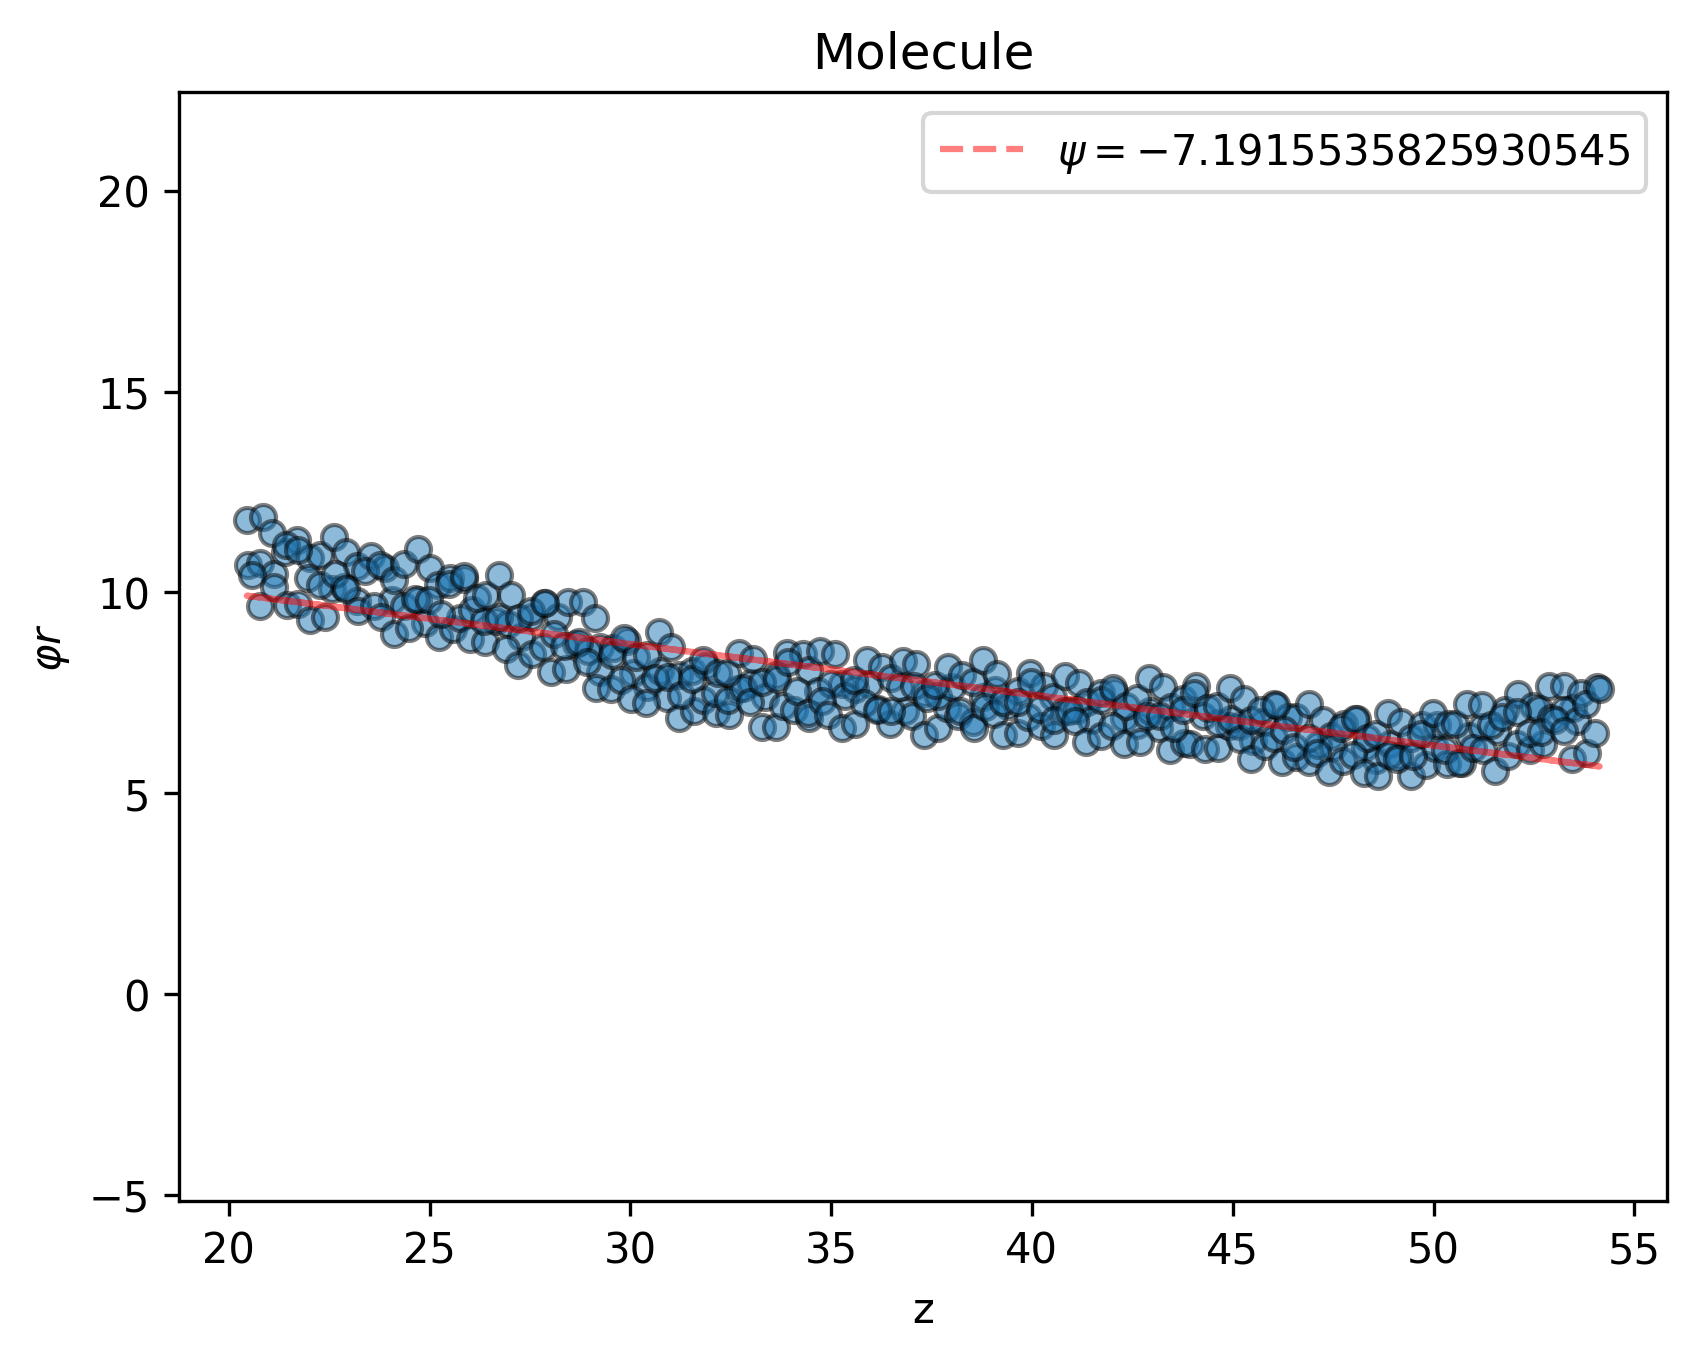

In [8]:
# --- Test Correct Loading of the Data: Time 0 ---
mol = 4
com = protein.center_of_mass()
mol_coords = (chains[3*mol].select_atoms(atom_gp) + chains[3*mol + 1].select_atoms(atom_gp)+ chains[3*mol + 2].select_atoms(atom_gp)).positions - np.array([com[0], com[1], 0.0])
mol_coords_filt = tw.remove_ends(0.5, mol_coords) / 10
r, phi, z = tw.cyl_proj(mol_coords_filt)
arc = r*phi

# Plot: Horizontal
plt.figure(dpi=300)
plt.scatter(z, arc, edgecolors="k", alpha=0.5)

tau, b, dr2 = tw.ortreglinfit(z, arc)
psi_pt = np.rad2deg(np.atan(tau))
plt.plot(z, tau*z + b, "--", alpha=0.5, color="r", label=rf"$\psi = {psi_pt}$")

plt.xlabel("z")
plt.ylabel(r"$\varphi r$")
plt.title("Molecule")

plt.legend()
plt.axis("equal")
plt.show()

In [4]:
molecules = int(len(chains)/3)
psi = np.zeros(molecules)
rad = np.zeros(molecules)
r2 = np.zeros(molecules)

for mol in range(molecules):
    mol_coords = (chains[3*mol].select_atoms(atom_gp) + chains[3*mol + 1].select_atoms(atom_gp)+ chains[3*mol + 2].select_atoms(atom_gp)).positions - np.array([com[0], com[1], 0.0])
    mol_coords_filt = tw.remove_ends(0.5, mol_coords) / 10
    r, phi, z = tw.cyl_proj(mol_coords_filt)
    arc = r*phi

    # --- FIT ---
    tau, _, dr2 = tw.ortreglinfit(z, arc)
    psi[mol] = np.rad2deg(np.atan(tau))
    rad[mol] = np.mean(r)
    r2[mol] = dr2

In [5]:
# --- Vis All Molecules ---
for mol in range(molecules):
    mol_coords = (chains[3*mol].select_atoms(atom_gp) + chains[3*mol + 1].select_atoms(atom_gp)+ chains[3*mol + 2].select_atoms(atom_gp)).positions - np.array([com[0], com[1], 0.0])
    mol_coords_filt = tw.remove_ends(0.5, mol_coords) / 10
    r, phi, z = tw.cyl_proj(mol_coords_filt)
    arc = r*phi

    # --- FIT ---
    tau, _, _ = tw.ortreglinfit(z, arc)
    psi[mol] = np.rad2deg(np.atan(tau))
    rad[mol] = np.mean(r)

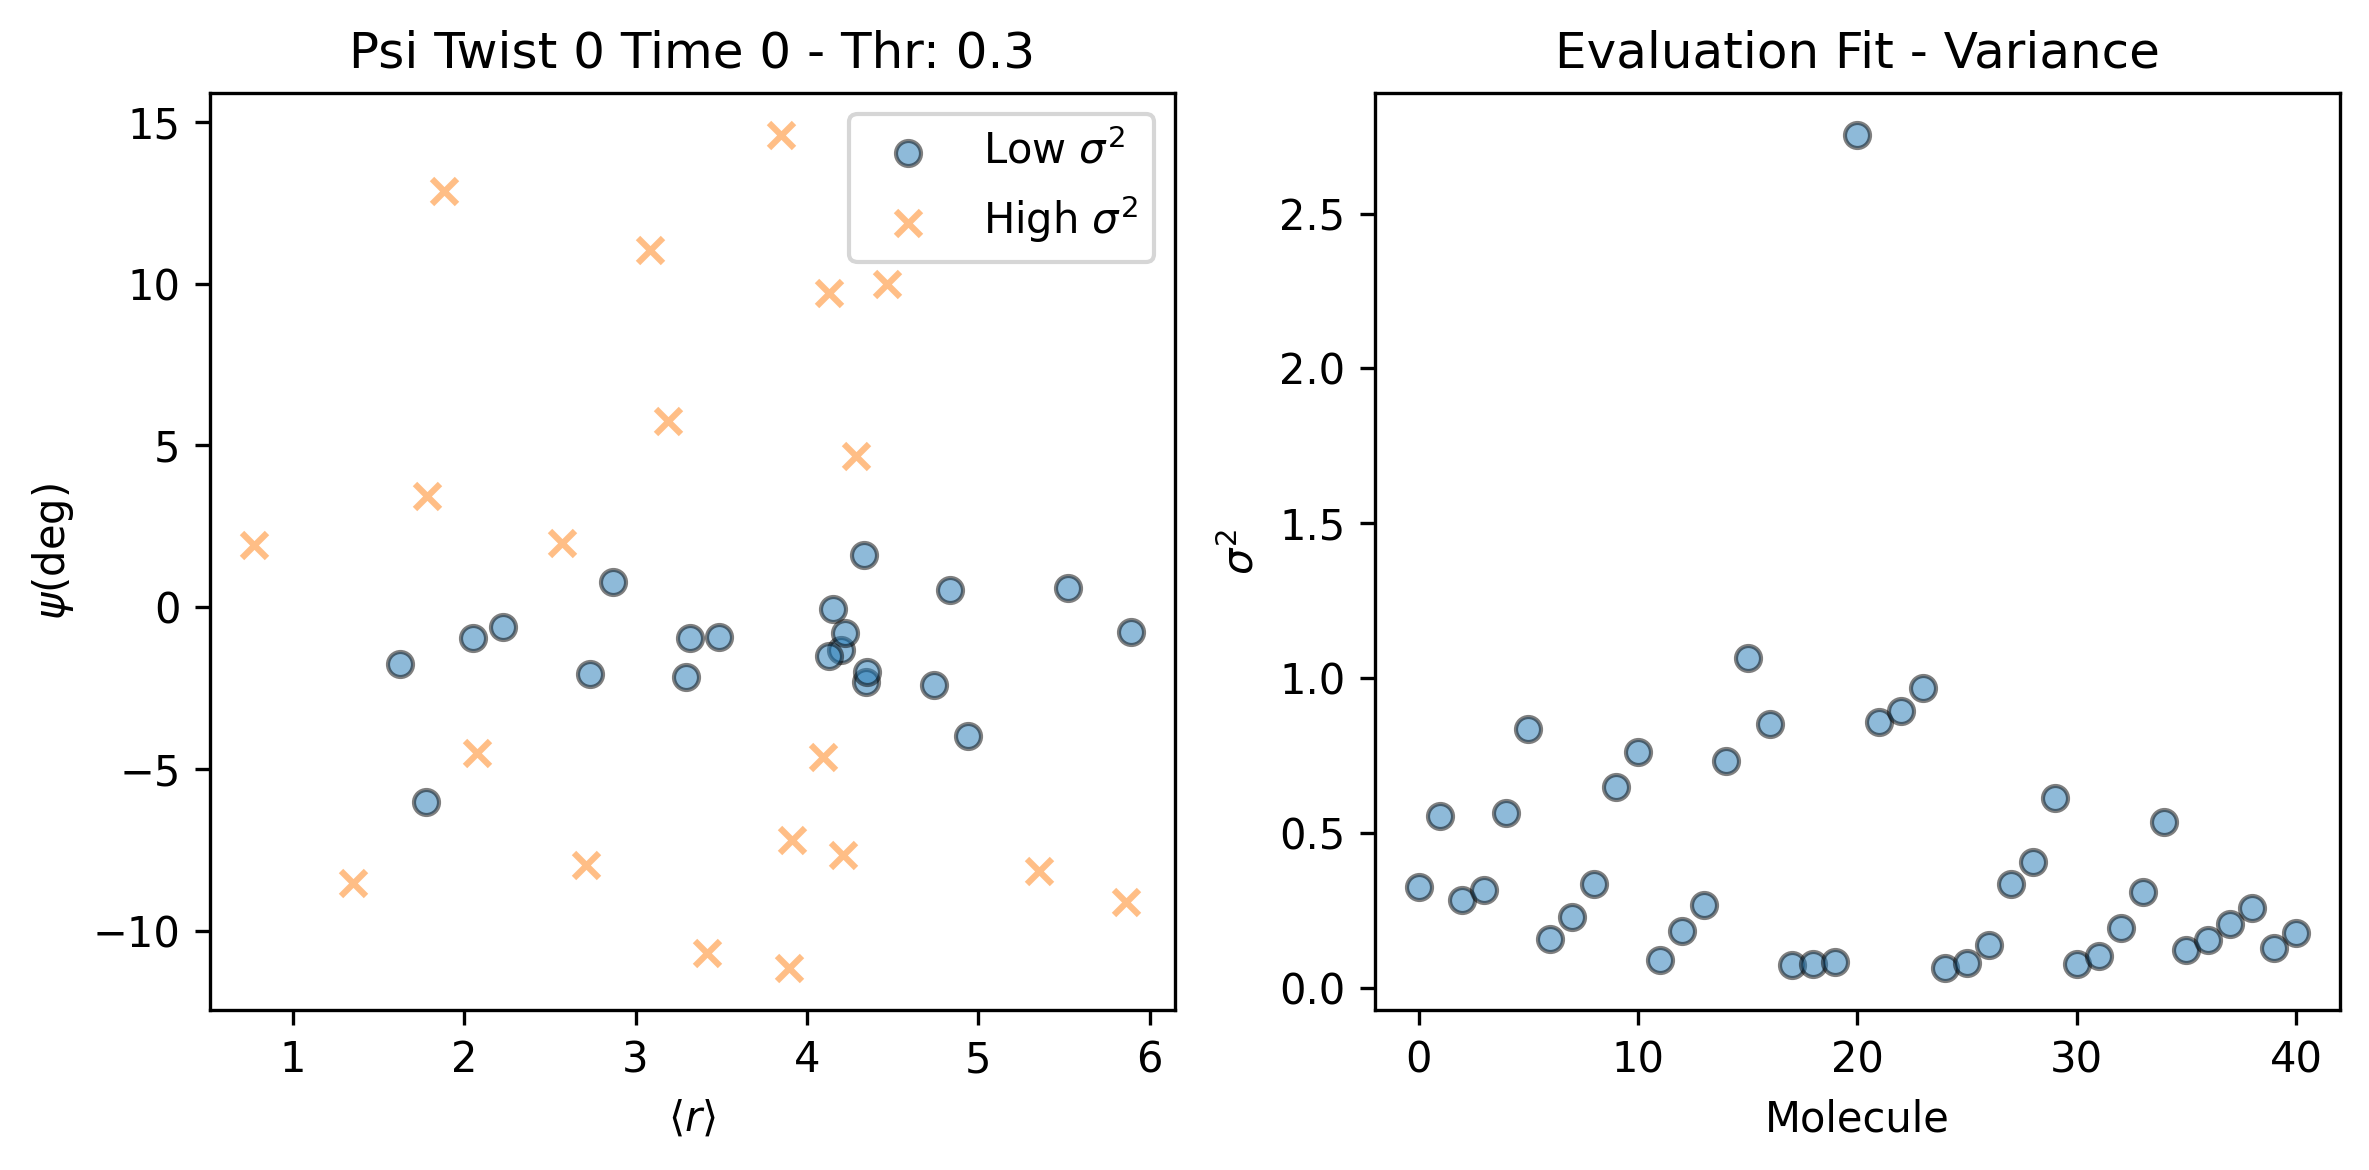

In [6]:
fig, ax = plt.subplots(1, 2, dpi=300, figsize=(8, 4))

# --- Classification ---
threshold = 0.3 
mask = (r2 < threshold)

psi_gr2 = psi[mask]
rad_gr2 = rad[mask]
psi_br2 = psi[~mask]
rad_br2 = rad[~mask]

# --- Psi vs r ---
ax[0].scatter(rad_gr2, psi_gr2, edgecolors="k", alpha=0.5, label=rf"Low $\sigma^2$")
ax[0].scatter(rad_br2, psi_br2, marker="x", alpha=0.5, label=r"High $\sigma^2$")
ax[0].set_xlabel(r"$\langle r \rangle$")
ax[0].set_ylabel(r"$\psi$(deg)")
ax[0].set_title(f"Psi Twist {twist} Time 0 - Thr: {threshold}")
ax[0].legend()

ax[1].scatter(range(molecules), r2, edgecolors="k", alpha=0.5)
ax[1].set_xlabel("Molecule")
ax[1].set_ylabel(r"$\sigma^2$")
ax[1].set_title(f"Evaluation Fit - Variance")

plt.tight_layout()
plt.show()